In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score

In [45]:
data = pd.read_csv('/content/weatherHistory.csv')

data.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [46]:
print(data.shape)

print(data.columns)

print(data.info())

print(data.describe())

data.head()

(96453, 12)
Index(['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)',
       'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
       'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover',
       'Pressure (millibars)', 'Daily Summary'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [47]:
print(data.isnull().sum())

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64


In [48]:
data["Precip Type"] = data["Precip Type"].fillna("Unknown")

In [49]:
data = data.drop(columns=[
    "Formatted Date",
    "Daily Summary"
])

In [50]:
label_precip = LabelEncoder()
data["Precip Type"] = label_precip.fit_transform(data["Precip Type"])

label_summary = LabelEncoder()
data["Summary"] = label_summary.fit_transform(data["Summary"])

In [51]:
X = data.drop("Summary", axis=1)

y = data["Summary"]

In [52]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [54]:
X_train = torch.tensor(X_train, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train.values, dtype=torch.long)

y_test = torch.tensor(y_test.values, dtype=torch.long)

In [55]:
class WeatherModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.fc1 = nn.Linear(X_train.shape[1],64)

        self.fc2 = nn.Linear(64,32)

        # Fix: Use the correct number of classes from the LabelEncoder
        self.fc3 = nn.Linear(32, len(label_summary.classes_))

    def forward(self,x):

        x = torch.relu(self.fc1(x))

        x = torch.relu(self.fc2(x))

        x = self.fc3(x)

        return x

model = WeatherModel()

print(model)

WeatherModel(
  (fc1): Linear(in_features=9, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=27, bias=True)
)


In [56]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(),lr=0.001)

In [57]:
losses = []

epochs = 50

for epoch in range(epochs):

    outputs = model(X_train)

    loss = criterion(outputs,y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    losses.append(loss.item())

    if (epoch+1)%5==0:

        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

Epoch 5/50, Loss: 3.2656
Epoch 10/50, Loss: 3.1949
Epoch 15/50, Loss: 3.1105
Epoch 20/50, Loss: 3.0024
Epoch 25/50, Loss: 2.8640
Epoch 30/50, Loss: 2.6943
Epoch 35/50, Loss: 2.4982
Epoch 40/50, Loss: 2.2904
Epoch 45/50, Loss: 2.0918
Epoch 50/50, Loss: 1.9202


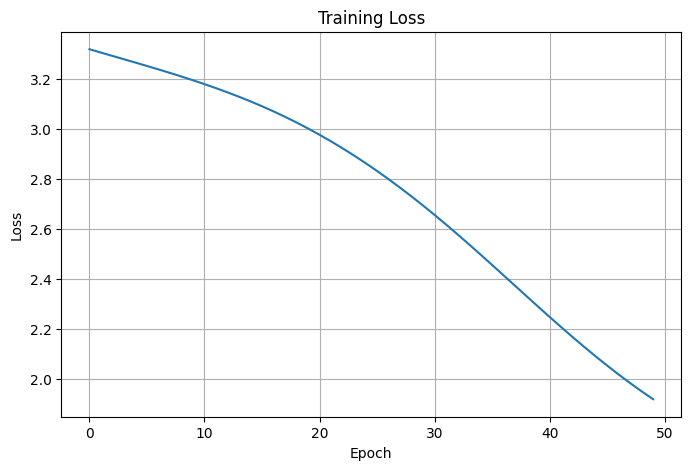

In [58]:
plt.figure(figsize=(8,5))

plt.plot(losses)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.grid(True)

plt.show()

In [59]:
with torch.no_grad():

    predictions = model(X_test)

    _, predicted = torch.max(predictions,1)

In [60]:
accuracy = accuracy_score(y_test,predicted)

print("Accuracy :",accuracy*100,"%")

Accuracy : 36.877300295474576 %


In [61]:
print("Actual Labels")

print(y_test[:10])

print()

print("Predicted Labels")

print(predicted[:10])

Actual Labels
tensor([17, 17, 17, 18, 17, 17, 17, 17, 17, 19])

Predicted Labels
tensor([19, 19, 19, 19, 12, 17, 19, 19, 19, 17])


In [62]:
print("""
Conclusion

1. Loaded the Weather Dataset.
2. Preprocessed the data.
3. Encoded categorical values.
4. Standardized numerical features.
5. Built a PyTorch Neural Network.
6. Trained the model using CrossEntropyLoss and Adam optimizer.
7. Evaluated the model using Accuracy.
8. Visualized the training loss.
""")


Conclusion

1. Loaded the Weather Dataset.
2. Preprocessed the data.
3. Encoded categorical values.
4. Standardized numerical features.
5. Built a PyTorch Neural Network.
6. Trained the model using CrossEntropyLoss and Adam optimizer.
7. Evaluated the model using Accuracy.
8. Visualized the training loss.

